<a href="https://colab.research.google.com/github/jliang-us/SHREK_Project/blob/main/SHREK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Predicting food swamps at the census tract level**




$$
\textbf{CIS545 Group 78} \\[0.5em]
\text{Statistical Healthful Retail-food Environment Knowledge (SHREK) Team} \\
\textit{Katherine Li, Jackie Liang, Connor Parker}
$$


#1. Introduction and Background

We aim to predict access to healthful food retailers, i.e., the presence of “food swamps”, across the United States at the census tract level. As opposed to food deserts, food swamps are greater predictors of health outcomes and are more relevant for urban settings where food swamps are prevalent. Despite growing evidence of their importance and relevance, existing research in this area is sparse as food swamps were only defined in 2011 by the CDC.

For our project, we will create a dataset that has the food swamp data and characteristics of the area by combining the CDC's last published food swamp data in 2012 and link it to Census ACS data for the relevant year to get hundreds of variables describing the census tract. We will then use machine learning to generate models that can predict food swamps based on demographic, housing, and socio-economic characteristics of the census tract.


**Data Overview**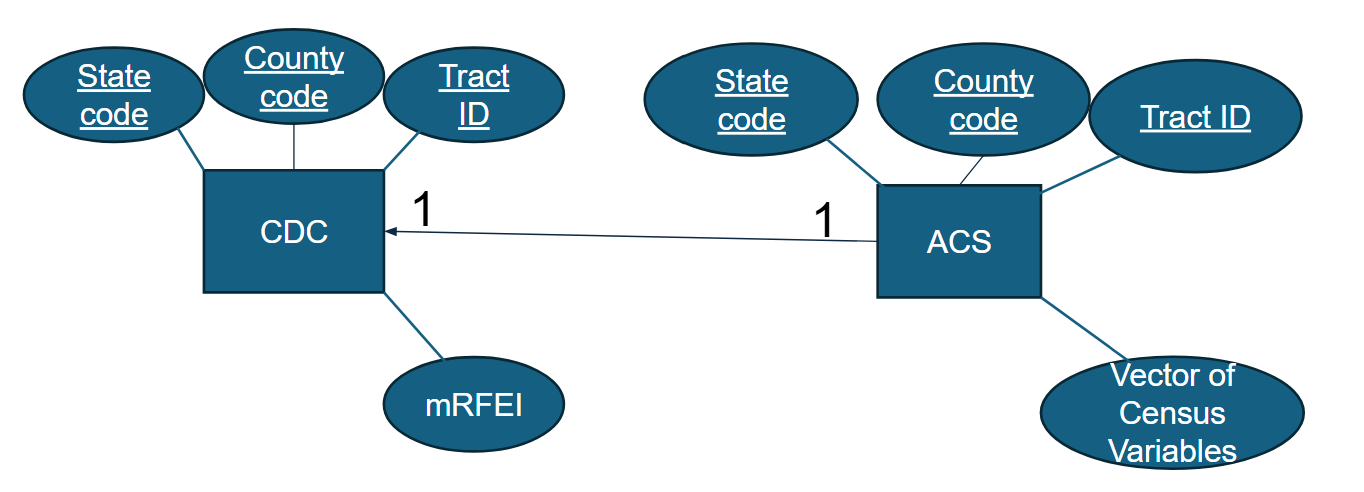

To provide a data summary, our project uses a dataset created by linking two datasets from the Center for Disease Control (CDC) and the Census American Community Survey (ACS). The primary keys we use to merge these entities is the state, county, and fips codes. The CDC entity brings in our dependent variable which is derived from the modified Retail Food Environment Index. The Census ACS entity contains many attributes, which relate to the ACS table. These attributes include characteristics such as the number of people in a household, race, income, and mode of transportation for that census tract area.

##Set up

In [ ]:
!pip install openpyxl==3.1.5
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import openpyxl
import requests
import os
from google.colab import userdata, drive
import time
from typing import List, Dict
from requests.adapters import HTTPAdapter #for api request
from urllib3.util.retry import Retry # for api requests

#visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#geospatial packages
import geopandas as gpd
from shapely.geometry import Point, Polygon

#sklearn for ML
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import r_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

In [ ]:
from google.colab import drive
#Drive mounting optional; files reuploaded into project GCS bucket
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
API_KEY = '35eeec018f5a100eb601164ed9ca4a7e7c1c8897'

## Loading in our Datasets

We use the Census API key for greater flexibility on the rates and limits of making requests to their ACS data. Without a key, users are limited to 50 variables per query and only 500 queries per day. See the [Census Documentation for more details](https://www.census.gov/data/developers/guidance/api-user-guide.html). The Census provides API keys free through their [signup](https://api.census.gov/data/key_signup.html).


The CDC published a copy of their modified Retail Food Environment Index data (mRFREI) by census tract in a 2012 release that is public and free to access in their stacks. It can be accessed [here](https://stacks.cdc.gov/view/cdc/61367).

There are 65K rows, with each row being a census tract and their calculated mRFREI score. The fips column contains the fips code for the state, county, and census tract. We will use this fips code later to link our Census ACS variables to it.

### CDC Data

In [ ]:
#mrfei_census_tract = pd.read_excel('/content/drive/MyDrive/SHREK_FoodSwamp_Project/cdc_61367_DS2.xlsx',
 #                                  dtype={'fips': str})
url = 'https://storage.googleapis.com/cis545-shrek-project/cdc_61367_DS2.xlsx'
mrfei_census_tract = pd.read_excel(url, dtype={'fips': str})
#breakout the fips into the state county and tract fips codes
mrfei_census_tract['stateFIPS'] = mrfei_census_tract['fips'].astype(str).str[:2]
mrfei_census_tract['county'] = mrfei_census_tract['fips'].astype(str).str[2:5]
mrfei_census_tract['tract'] = mrfei_census_tract['fips'].astype(str).str[5:]

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [ ]:
print(mfrei_census_tract.shape)
print(mfrei_census_tract[mfrei_census_tract["fips"].notnull()])
mfrei_census_tract.head()

(65345, 6)
      state         fips      mrfei stateFIPS county   tract
0        AL  01001020100  16.666667        01    001  020100
1        AL  01001020200  16.666667        01    001  020200
2        AL  01001020300  17.647059        01    001  020300
3        AL  01001020400  13.333333        01    001  020400
4        AL  01001020500       6.25        01    001  020500
...     ...          ...        ...       ...    ...     ...
65340    WY  56043000200          0        56    043  000200
65341    WY  56043000301  13.333333        56    043  000301
65342    WY  56043000302  13.333333        56    043  000302
65343    WY  56045951100         50        56    045  951100
65344    WY  56045951300  18.181818        56    045  951300

[65345 rows x 6 columns]


,state,fips,mrfei,stateFIPS,county,tract
0,AL,01001020100,16.666667,01,001,020100
1,AL,01001020200,16.666667,01,001,020200
2,AL,01001020300,17.647059,01,001,020300
3,AL,01001020400,13.333333,01,001,020400
4,AL,01001020500,6.25,01,001,020500


### ACS Data

We will get data at the the state level for all tracts using tract*. The Census does not support using the wildcare for the state geography, as such, our plan will be to get all the tables for a state one state at a time. We will save the state level census tract data to csv in a folder, and then merge the csvs together.

Since we are trying to get multiple variables from the Census, we attempted defining a list of unique variables to iterate through 50 variables at a time to stay within the rate limitations. However, this process can be grouped up as seen in the Census API docs using the get group() function that will return all variables associated with the table and there are no max variable limitations. As such, our approach will be to define a table_ids list, and select a list of the tables that we want to get from the Census. We selected a list of tables from a number of concepts spanning demographics, age, and other characteristics while avoiding tables that are very specific cross tables (eg, sex by race, age by race).


In [ ]:
#Corrected merge to avoid duplicate tracts
def fetch_state_table_data(table_id: str, state: str) -> pd.DataFrame:
    """Fetch all data for a table in a state using group()"""
    url = "https://api.census.gov/data/2011/acs/acs5"
    params = {
        'get': f'group({table_id})',  # Fetch all variables for the table
        'for': 'tract:*',  # Get all tracts
        'in': f'state:{state}',  # Limit to the state
        'key': API_KEY
    }

    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            data = response.json()
            if len(data) > 1:
                df = pd.DataFrame(data[1:], columns=data[0])
                # Create a unique tract identifier
                df['tract_id'] = df['state'] + df['county'] + df['tract']
                df = df.drop_duplicates(subset=['tract_id'])  # Remove duplicates
                return df
            else:
                print(f"No data returned for table {table_id} in state {state}.")
                return pd.DataFrame()
        else:
            print(f"Error {response.status_code}: {response.text}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Exception for table {table_id} in state {state}: {e}")
        return pd.DataFrame()

def process_all_states(table_ids: list, state_fips_codes: list, output_dir: str):
    """Process all states and save data to CSV"""
    os.makedirs(output_dir, exist_ok=True)

    for state in state_fips_codes:
        file_path = os.path.join(output_dir, f"state_{state}_census_data.csv")
        if os.path.exists(file_path):
            print(f"Data for state {state} already exists. Skipping...")
            continue

        print(f"Processing state {state}...")
        merged_data = None

        for table_id in table_ids:
            print(f"Fetching table {table_id} for state {state}...")
            table_df = fetch_state_table_data(table_id, state)

            if not table_df.empty:
                # Add table_id prefix to all columns except geographic identifiers
                geo_cols = ['tract_id', 'state', 'county', 'tract']
                data_cols = [col for col in table_df.columns if col not in geo_cols]
                table_df = table_df.rename(columns={col: f"{table_id}_{col}" for col in data_cols})

                if merged_data is None:
                    merged_data = table_df
                else:
                    # Merge on tract_id to maintain one row per tract
                    merged_data = pd.merge(
                        merged_data,
                        table_df,
                        on=['tract_id', 'state', 'county', 'tract'],
                        how='outer'
                    )

        if merged_data is not None:
            print(f"Saving data for state {state}...")
            # Sanitize and save to CSV
            sanitized_df = sanitize_dataframe(merged_data)
            save_state_data_to_csv(state, sanitized_df, output_dir)
        else:
            print(f"No data fetched for state {state}.")

def sanitize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Convert all data to strings to handle mixed types and symbols"""
    return df.astype(str).replace({'nan': None, 'None': None})

def save_state_data_to_csv(state: str, state_data: pd.DataFrame, output_dir: str):
    """Save state data to a CSV file"""
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, f"state_{state}_census_data.csv")
    state_data.to_csv(file_path, index=False)
    print(f"Data for state {state} saved to {file_path}")

if __name__ == "__main__":
    state_fips_codes = mfrei_census_tract['stateFIPS'].dropna().astype(str).unique().tolist()
    print(f"Unique state FIPS codes: {state_fips_codes}")

    # Define table IDs to fetch
    table_ids = [
    'B01001', 'B01002', 'B01003', # Sex by age (detailed), median age, total pop
    'B02001',  # Race
    'B03002',  # Hispanic or Latino Origin by Race
    'B08301',  #  Means of Transportation to Work

    # Household and Family
    'B11001',  # Household Type

    # Income and Economic Indicators
    'B19013',  # Median household income
    'B19057',  # Public Assistance Income
    'B19058',  # Public Assistance Income or SNAP
    'B19083',  # GINI Index of Income Inequality

    # Housing Characteristics
    'B25001',  # Housing Units
    'B25002',  # Occupancy Status
    'B25003',  # Tenure (Owner/Renter)
    'B25004',  # Vacancy Status
    'B25064',  # Median Gross Rent
    'B25077',  # Median Value (Dollars)

    # addtnl tables
    'B15002',  # Educational attainment by sex for population 25+ years
    'B23025',  # Employment status
    'B17001',  # Poverty status in the past 12 months
    'B25014',  # Tenure by Occupants per Room
    'B25034',  # Year Structure Built
    'B25071',  # Median Gross Rent as a Percentage of Household Income
    ]

    output_dir = "/content/drive/MyDrive/census_data_2"
    process_all_states(table_ids, state_fips_codes, output_dir)

    print("All states processed. Data saved to CSV files.")


Unique state FIPS codes: ['01', '02', '04', '05', '06', '80', '81', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56']
Processing state 01...
Fetching table B01001 for state 01...
Fetching table B01002 for state 01...
Fetching table B01003 for state 01...
Fetching table B02001 for state 01...
Fetching table B03002 for state 01...
Fetching table B08301 for state 01...
Fetching table B11001 for state 01...
Fetching table B19013 for state 01...
Fetching table B19057 for state 01...
Fetching table B19058 for state 01...
Fetching table B19083 for state 01...
Fetching table B25001 for state 01...
Fetching table B25002 for state 01...
Fetching table B25003 for state 01...
Fetching table B25004 for state 01...
Fetching table B25064 for state 01...
Fetching table B25077 for state

Since we saved our census tract data by state in our Google Drive, the function below will merge our csvs together and also only keep columns of the ACS variable that are estimates and not the margin of error.

In [ ]:
import glob

In [ ]:
def combine_and_clean_census_data(input_dir: str, output_file: str):
    """Combine and clean all state census CSV files, ensuring consistent column order."""
    # Find all CSV files in the input directory
    csv_files = glob.glob(os.path.join(input_dir, "*.csv"))
    print(f"Found {len(csv_files)} CSV files in {input_dir}.")

    # Identify the full set of columns across all files
    all_columns = set()
    for file in csv_files:
        df = pd.read_csv(file, nrows=0)  # Only read the header row
        all_columns.update(df.columns)
    all_columns = sorted(all_columns)  # Sort to ensure consistent order
    print(f"Total unique columns across all files: {len(all_columns)}")

    # Combine all files with consistent column order
    combined_df = pd.DataFrame(columns=all_columns)  # Initialize an empty DataFrame with all columns
    for file in csv_files:
        print(f"Processing file: {file}")
        df = pd.read_csv(file, dtype=str)  # Read as strings to handle mixed types
        df = df.reindex(columns=all_columns, fill_value=pd.NA)  # Reorder and fill missing columns with NaN
        combined_df = pd.concat([combined_df, df], ignore_index=True)

    # Debug: Check for columns with missing values
    print("Missing value count per column:")
    print(combined_df.isna().sum())

    # keep all columns but margin of error, annotations
    columns_to_keep = [col for col in combined_df.columns if not col.endswith(("_M", "M", "_MA", "EA", "MA"))]
    cleaned_df = combined_df[columns_to_keep]

    # Save the cleaned combined data
    cleaned_df.to_csv(output_file, index=False)
    print(f"Combined and cleaned data saved to {output_file}.")

In [ ]:
# Define input and output paths
input_dir = "/content/drive/MyDrive/census_data_2"
output_file = "combined_census_data_cleaned.csv"

In [ ]:
combine_and_clean_census_data(input_dir, output_file)

Found 50 CSV files in /content/drive/MyDrive/census_data_2.
Total unique columns across all files: 1106
Processing file: /content/drive/MyDrive/census_data_2/state_01_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_02_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_04_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_05_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_06_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_09_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_10_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_11_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_12_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_13_census_data.csv
Processing file: /content/drive/MyDrive/census_data_2/state_15_census_data.csv
Processing file: /content/d

After merging, we just want to check that we have the expected amount of rows / unique geo_ids that we should expect!

In [ ]:
def get_csv_shapes(input_dir: str):
    """Print the shape of each CSV file in the directory."""
    # Find all CSV files in the directory
    csv_files = glob.glob(os.path.join(input_dir, "*.csv"))
    print(f"Found {len(csv_files)} CSV files in {input_dir}.")

    # Check the shape of each file
    for file in csv_files:
        df = pd.read_csv(file, dtype=str)  # Read as strings to avoid type conflicts
        print(f"File: {os.path.basename(file)}, Shape: {df.shape}")

# Define the directory containing the CSV files
input_dir = "/content/drive/MyDrive/census_data_2"

# Run the shape check
get_csv_shapes(input_dir)


Found 50 CSV files in /content/drive/MyDrive/census_data_2.
File: state_01_census_data.csv, Shape: (1181, 1106)
File: state_02_census_data.csv, Shape: (167, 1106)
File: state_04_census_data.csv, Shape: (1526, 1106)
File: state_05_census_data.csv, Shape: (686, 1106)
File: state_06_census_data.csv, Shape: (8057, 1106)
File: state_09_census_data.csv, Shape: (833, 1106)
File: state_10_census_data.csv, Shape: (218, 1106)
File: state_11_census_data.csv, Shape: (179, 1106)
File: state_12_census_data.csv, Shape: (4245, 1106)
File: state_13_census_data.csv, Shape: (1969, 1106)
File: state_15_census_data.csv, Shape: (351, 1106)
File: state_16_census_data.csv, Shape: (298, 1106)
File: state_17_census_data.csv, Shape: (3123, 1106)
File: state_18_census_data.csv, Shape: (1511, 1106)
File: state_19_census_data.csv, Shape: (825, 1106)
File: state_20_census_data.csv, Shape: (770, 1106)
File: state_21_census_data.csv, Shape: (1115, 1106)
File: state_22_census_data.csv, Shape: (1148, 1106)
File: state_2

In [ ]:
def check_unique_geo_ids(input_dir: str):
    """Check the number of unique GEO_IDs in each file."""
    csv_files = glob.glob(os.path.join(input_dir, "*.csv"))
    for file in csv_files:
        df = pd.read_csv(file, dtype=str)
        if "GEO_ID" in df.columns:
            unique_geo_ids = df["GEO_ID"].nunique()
            total_rows = len(df)
            print(f"File: {os.path.basename(file)}, Total Rows: {total_rows}, Unique GEO_IDs: {unique_geo_ids}")
        else:
            print(f"File: {os.path.basename(file)} is missing GEO_ID column.")

# Define input directory
input_dir = "/content/drive/MyDrive/census_data"

# Run the GEO_ID check
check_unique_geo_ids(input_dir)


In [ ]:
df_cleaned = pd.read_csv('/content/combined_census_data_cleaned.csv')

#Remove the first prefix before the first underscore due to the merges
df_cleaned.columns = df_cleaned.columns.str.replace(r'^[^_]+_', '', regex=True)

# Handle duplicate column names by keeping only one unique set
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]
print(df_cleaned[df_cleaned["id"].notnull()])
print(df_cleaned.shape)
print(df_cleaned.head())


       B01001_001E  B01001_002E  B01001_003E  B01001_004E  B01001_005E  \
0             1768          877           27           74           92   
1             2167          979           58           59           96   
2             3337         1495           49          134          134   
3             4379         2066          162           92           99   
4            10197         5089          413          427          497   
...            ...          ...          ...          ...          ...   
71802         3312         1762          108           95          158   
71803         2769         1388          122          137           81   
71804         2291         1144           71           60           96   
71805         3082         1779           40           72          139   
71806         4062         1966          172          135           87   

       B01001_006E  B01001_007E  B01001_008E  B01001_009E  B01001_010E  ...  \
0               10            6 

We need to restore the leading zeroes in the county, state, and tract. We will use this to merge with the CDC data.

In [ ]:
# Restore leading zeros for 'state' (2 digits) and 'county' (3 digits)
if 'state' in df_cleaned.columns:
    df_cleaned['state'] = df_cleaned['state'].astype(str).str.zfill(2)

if 'county' in df_cleaned.columns:
    df_cleaned['county'] = df_cleaned['county'].astype(str).str.zfill(3)

if 'tract' in df_cleaned.columns:
    df_cleaned['tract'] = df_cleaned['tract'].astype(str).str.zfill(6)

# Rename 'state' to 'stateFIPS' in df_cleaned to match the column name in mrfei_census_tract
df_cleaned.rename(columns={'state': 'stateFIPS'}, inplace=True)

#prepare for merge by converting all to string
mrfei_census_tract['stateFIPS'] = mrfei_census_tract['stateFIPS'].astype(str)
mrfei_census_tract['county'] = mrfei_census_tract['county'].astype(str)
mrfei_census_tract['tract'] = mrfei_census_tract['tract'].astype(str)

df_cleaned['stateFIPS'] = df_cleaned['stateFIPS'].astype(str)
df_cleaned['county'] = df_cleaned['county'].astype(str)
df_cleaned['tract'] = df_cleaned['tract'].astype(str)

# Remove whitespaces
mrfei_census_tract['stateFIPS'] = mrfei_census_tract['stateFIPS'].str.strip()
mrfei_census_tract['county'] = mrfei_census_tract['county'].str.strip()
mrfei_census_tract['tract'] = mrfei_census_tract['tract'].str.strip()

df_cleaned['stateFIPS'] = df_cleaned['stateFIPS'].str.strip()
df_cleaned['county'] = df_cleaned['county'].str.strip()
df_cleaned['tract'] = df_cleaned['tract'].str.strip()

# Ensure proper zero-padding
mrfei_census_tract['stateFIPS'] = mrfei_census_tract['stateFIPS'].str.zfill(2)
mrfei_census_tract['county'] = mrfei_census_tract['county'].str.zfill(3)
mrfei_census_tract['tract'] = mrfei_census_tract['tract'].str.zfill(6)

df_cleaned['stateFIPS'] = df_cleaned['stateFIPS'].str.zfill(2)
df_cleaned['county'] = df_cleaned['county'].str.zfill(3)
df_cleaned['tract'] = df_cleaned['tract'].str.zfill(6)


# Perform the left join
baseline_df = mrfei_census_tract.merge(df_cleaned, on=['stateFIPS', 'county', 'tract'], how='left')

# Display the first few rows of the resulting DataFrame
print(baseline_df.shape)
print(baseline_df.head())
#baseline_df.to_csv('/content/drive/MyDrive/SHREK_FoodSwamp_Project/baseline_df.csv', index=False) #downloaded and then uploaded into a public google cloud bucket

(65345, 273)
  state         fips      mrfei stateFIPS county   tract  B01001_001E  \
0    AL  01001020100  16.666667        01    001  020100       1768.0   
1    AL  01001020200  16.666667        01    001  020200       2167.0   
2    AL  01001020300  17.647059        01    001  020300       3337.0   
3    AL  01001020400  13.333333        01    001  020400       4379.0   
4    AL  01001020500       6.25        01    001  020500      10197.0   

   B01001_002E  B01001_003E  B01001_004E  ...  B25034_005E  B25034_006E  \
0        877.0         27.0         74.0  ...        161.0        148.0   
1        979.0         58.0         59.0  ...         96.0        240.0   
2       1495.0         49.0        134.0  ...        114.0        318.0   
3       2066.0        162.0         92.0  ...         91.0        443.0   
4       5089.0        413.0        427.0  ...        545.0        392.0   

   B25034_007E  B25034_008E  B25034_009E  B25034_010E  B25064_001E  \
0        187.0         26.0

### Census Meta Data
This table brings in the Census variables and their corresponding labels that describe what the variables are. Since we are working with hundreds of variables, we won't replace the variable names before the feature selection. Once we do the feature selection, we will replace the selected variables with their descriptive names.

In [ ]:
#metadata labels
dataset = "acs/acs5"  # Example: American Community Survey 5-Year Data
year = "2011"  # Specify the year of the data
url = f"https://api.census.gov/data/{year}/{dataset}/variables.json"

# Request metadata
response = requests.get(url)
if response.status_code == 200:
    variables = response.json()['variables']

    # Parse the metadata into a DataFrame
    metadata = pd.DataFrame([
        {"variable": var, "label": details.get("label", ""), "concept": details.get("concept", "")}
        for var, details in variables.items()
    ])

    # Save metadata to a CSV file for future use
    metadata.to_csv("census_metadata.csv", index=False)

    print("Metadata saved to census_metadata.csv")
else:
    print(f"Failed to retrieve metadata: {response.status_code}")

# Load the metadata as a table (if previously saved)
census_metadata = pd.read_csv("census_metadata.csv")

census_metadata

Metadata saved to census_metadata.csv


,variable,label,concept
0,for,Census API FIPS 'for' clause,Census API Geography Specification
1,in,Census API FIPS 'in' clause,Census API Geography Specification
2,ucgid,Uniform Census Geography Identifier clause,Census API Geography Specification
3,B99104_007E,Estimate!!Total!!Not living with own grandchil...,IMPUTATION OF LENGTH OF TIME GRANDPARENT RESPO...
4,B24022_060E,Estimate!!Total!!Female!!Service occupations!!...,SEX BY OCCUPATION AND MEDIAN EARNINGS IN THE P...
...,...,...,...
21066,B25124_022E,Estimate!!Total!!Owner occupied!!3-person hous...,TENURE BY HOUSEHOLD SIZE BY UNITS IN STRUCTURE
21067,B16005_017E,Estimate!!Total!!Native!!Speak Asian and Pacif...,NATIVITY BY LANGUAGE SPOKEN AT HOME BY ABILITY...
21068,B08113_054E,Estimate!!Total!!Worked at home!!Speak other l...,MEANS OF TRANSPORTATION TO WORK BY LANGUAGE SP...
21069,B06009_006E,Estimate!!Total!!Graduate or professional degree,PLACE OF BIRTH BY EDUCATIONAL ATTAINMENT IN TH...


## Exploratory Data Analysis

In our Exploratory Data Analysis (EDA), we will take a closer look at our dataset and check for any irregularities with our data. This led to removing observations due to a discrepancy between CDC and
Census id's, and identifying Census annotation values in the variables. We then inspect our binary dependent variable, swamp, for its distribution that is slightly imbalanced and examine variables that are correlated with it. Since our project's goal is to use ML techniques for feature selection, we test a baseline model of a logistic regression with a naive feature selection strategy of selecting the top 20 variables in terms of correlation to our dependent variable, and we observe the class imbalance issue in our baseline model results that required testing class weights.

###Cleaning
Now that we have confirmed that our ACS data has merged with the CDC data, we will check for missing or erroneuous values. Since we will be using the mRFEI score to indicate whether a tract is a swamp, this variable is critical. We will drop any observations missing this value.


In [ ]:
#We've set up a GCS bucket and set to public for easier access to the baseline_df
url = 'https://storage.googleapis.com/cis545-shrek-project/baseline_df.csv'
baseline_df = pd.read_csv(url)

<ipython-input-6-6117f7a41850>:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  baseline_df = pd.read_csv(url)


In [ ]:
# Check rows where mrfei is either NaN, empty string, or just whitespace
missing_mrfei = baseline_df[
    (baseline_df['mrfei'].isna()) |  # Check for NaN
    (baseline_df['mrfei'] == '') |   # Check for empty string
    (baseline_df['mrfei'].str.isspace())  # Check for whitespace only
]

print(f"Number of rows with missing mrfei values: {len(missing_mrfei)}")
print("\nSample of rows with missing mrfei values:")
print(missing_mrfei)

Number of rows with missing mrfei values: 1245

Sample of rows with missing mrfei values:
      state         fips mrfei  stateFIPS  county   tract  B01001_001E  \
165      AL   1035960400   NaN          1      35  960400       3124.0   
183      AL   1039962900   NaN          1      39  962900       1753.0   
881      AL   1103005103   NaN          1     103    5103       1068.0   
894      AL   1105986800   NaN          1     105  986800          NaN   
1003     AL   1125010101   NaN          1     125   10101       3601.0   
...     ...          ...   ...        ...     ...     ...          ...   
65126    WI  55133203405   NaN         55     133  203405       4022.0   
65156    WI  55137960100   NaN         55     137  960100       2873.0   
65208    WI  55141010800   NaN         55     141   10800       2816.0   
65262    WY  56017940100   NaN         56      17  940100          NaN   
65263    WY  56017940200   NaN         56      17  940200          NaN   

       B01001_002E  B

Note: We noticed a large number of missing tract values due to no matches, and we will drop these rows leaving us with slightly more than 50K observations. Upon closer inspection, we find this is due to the CDC data using a different census tract code standard. For example, a specific tract was coded as "01001020800" in the CDC data. The ACS data had  this corresponding tract split into two different tract ids "01001020801" and "01001020802". We checked if this was an issue with our ACS data year, however, ACS census tract ids were all consistent across datasets for 2010 - 2012, as well as the 2010 Decennial census dataset. It is unclear exactly how the CDC came to these slightly different census tract ids.

In [ ]:
baseline_df = baseline_df[baseline_df["id"].notnull()] # if there is no id, there was no matching fips code due to differences in CDC and ACS fips codes
baseline_df = baseline_df[baseline_df["mrfei"].notnull()] # remove rows with missing mrfei as its needed for determining swamps, 0s are okay values
print(baseline_df.shape)

(50126, 273)


As for the ACS variables (indicated by the prefix B), we will need to replace certain values as described by their [documentation on annotations](https://www.census.gov/data/developers/data-sets/acs-1year/notes-on-acs-estimate-and-annotation-values.html).

We created a dictionary of all all annotations the Census uses for erroneuous values, and then checked all of our census variables for occurences.

In [ ]:
# List of erroneous/annotation values and their explanations
erroneous_values = {
    -666666666: "Estimate could not be computed due to small sample",
    -999999999: "Insufficient number of sample cases",
    -888888888: "Estimate or margin of error not applicable",
    -222222222: "Margin of error could not be computed",
    -333333333: "Margin of error could not be computed (median issue)",
    -555555555: "Margin of error not appropriate",
    "median-": "Median falls in the lowest interval",
    "median+": "Median falls in the highest interval",
    "***": "Margin of error issue (median issue)",
    "*****": "Margin of error not appropriate (controlled estimate)",
    "*": "Statistically significant difference",
    np.nan: "No data available"
}

# Filter for Census variable columns (those starting with 'B')
census_columns = [col for col in baseline_df.columns if col.startswith('B')]
# Count occurrences of annotated values in all Census columns
annotation_counts = {}
for value, explanation in erroneous_values.items():
    count = (baseline_df[census_columns] == value).sum().sum()
    annotation_counts[value] = count

# Display the total count of annotations
total_annotations = sum(annotation_counts.values())
print(f"Total annotations/errors in the dataset: {total_annotations}")
print("Breakdown by type of annotation:")
for key, val in annotation_counts.items():
    print(f"{key}: {val}")

# Replace erroneous values with NaN for easier handling
for value, explanation in erroneous_values.items():
    baseline_df[census_columns] = baseline_df[census_columns].replace(value, np.nan)
print("Replaced erroneous/annotation values in Census variables with NaN.")


Total annotations/errors in the dataset: 1935
Breakdown by type of annotation:
-666666666: 1935
-999999999: 0
-888888888: 0
-222222222: 0
-333333333: 0
-555555555: 0
median-: 0
median+: 0
***: 0
*****: 0
*: 0
nan: 0
Replaced erroneous/annotation values in Census variables with NaN.


The only case of errors are the "-666666666" errors which are due to insufficient sample sizes, and they are a rare occurance in the data.

In [ ]:
# Count the total number of cells in Census variable columns
total_cells = baseline_df[census_columns].size

# Calculate the percentage of annotations
percent_annotations = (total_annotations / total_cells) * 100

# Display the percentage of annotations
print(f"Percentage of annotation values in Census variables: {percent_annotations:.4f}%")


Percentage of annotation values in Census variables: 0.0146%


We will use a K-Nearest Neighbor method of imputing any NA values. While there are only a very small number of NaNs, we will attempt to preserve the rows with them without dropping them as we want to maintain at least 50K rows. The KNN method computes "neighbors" or similar rows based on their Census characteristics (and not whether they are swamps, deserts, etc). We use the 10 neighboring values to impute the missing value for the small number of values that are missing in our baseline_df.

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=10)
baseline_df[census_columns] = imputer.fit_transform(baseline_df[census_columns])

Lastly, we will check if there are any categorical variables that were brought in through the ACS tables. We expect count estimates for these ACS tables, but we will check anyhow if there are any categorical values. We confirm that these variables are count estimates.

In [ ]:
non_numeric_columns = baseline_df[census_columns].select_dtypes(include=['object', 'category']).columns
print(f"Non-numeric columns: {non_numeric_columns}")

# Check columns for unique values
for col in baseline_df[census_columns].columns:
    unique_values = baseline_df[col].dropna().unique()
    if len(unique_values) <= 50:  # we want to check if there are very low number of unique values that could suggest categorical data
        print(f"Column '{col}' might be binary or encoded. Unique values: {unique_values}")


Non-numeric columns: Index([], dtype='object')


### Defining mRFEI Features

The mRFEI is an index created by the CDC to be able to identify areas that are food deserts, food swamps, or healthful based on a "densitiy" approach that takes the proportion of healthful retailers in an area versus the number of total food retailers in the area.  

$\text{mRFEI} = 100 \times$ $ \frac{\text{number of healthful retailers in tract}}{\text{number of healthful retailers in tract} + \text{number of unhealthful retailers in tract}}$

Healthful retailers are defined by retailers with NAICS codes that correspond to supermarkets and larger grocery stores, supercenters, and produce stores. Less healthful retailers are defined as convenience stores, smaller grocery stores with fewer than 3 employees, and fast food restaurants.


In [ ]:
# baseline_df_clean is now the cleaned, merged
baseline_df_clean = baseline_df.copy()
baseline_df_clean['mrfei'] = pd.to_numeric(baseline_df_clean['mrfei'], errors='coerce')

median_mRFEI = baseline_df_clean['mrfei'].fillna(0).median()
print(f"The median mRFEI for our census tracts is {median_mRFEI:.2f}.")

The median mRFEI for our census tracts is 9.09.


The mRFEI score is then used to define thresholds based on the median mRFEI value. Areas with mRFEI's that are equal to 0 are considered food deserts, values above 0 and below the median mRFREI is considered a food swamp, and anything above the median is considered a healthful area:

$\text{mRFEI} = \begin{cases}
0 & \Rightarrow \text{ The tract is a food desert} \\
\in(0,\text{median}(\text{mRFEI})] & \Rightarrow \text{ The tract is a food swamp} \\
\in(\text{median}(\text{mRFEI}),100] & \Rightarrow \text{ The tract has good access to healthful food}
\end{cases}$

In [ ]:
# Create the mRFEI categories as dummy variables
baseline_df_clean['desert'] = baseline_df_clean['mrfei'] == 0
baseline_df_clean['swamp'] = (baseline_df_clean['mrfei'] > 0) & (baseline_df_clean['mrfei'] <= median_mRFEI)
baseline_df_clean['healthful'] = baseline_df_clean['mrfei'] > median_mRFEI

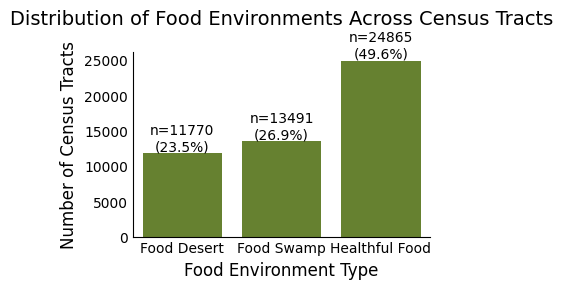

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts
counts = {
   'Food Environment': ['Food Desert', 'Food Swamp', 'Healthful Food'],
   'Count': [
       baseline_df_clean['desert'].sum(),
       baseline_df_clean['swamp'].sum(),
       baseline_df_clean['healthful'].sum()
   ]
}

# Calculate percentages
total = sum(counts['Count'])
percentages = [count/total * 100 for count in counts['Count']]

# Create figure
plt.figure(figsize=(4, 3)) #shrinking plots for large file size reasons

# Create bar plot
ax = sns.barplot(x='Food Environment', y='Count', data=counts, color='olivedrab')

# Add value labels on top of each bar
for i, (count, percentage) in enumerate(zip(counts['Count'], percentages)):
   ax.text(i, count, f'n={count}\n({percentage:.1f}%)',
           ha='center', va='bottom')

# Customize the plot
plt.title('Distribution of Food Environments Across Census Tracts', pad=20, fontsize=14)
plt.xlabel('Food Environment Type', fontsize=12)
plt.ylabel('Number of Census Tracts', fontsize=12)

#despine
sns.despine(top=True, right=True)

ax.tick_params(length=0)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

We find that nearly 50 percent (n = 24.8K) of census tracts would be considered tracts with good access to healthful retailers. Only 26.9% (n = 13.5K) of tracts are considered food swamps, and 23.5% (n = 11.8K) are food deserts.  

This distribution will be good for modeling, as there is not any severe imbalance and each class has a good sample. We will nonetheless use class weights, but we do not need to consider techniques like generating synthetic data to deal with this class imbalance.

### Summary Statistics

We will begin our explatory analysis with an examination of summary statistics and the distribution of certain key variables like the mRFEI which is then used to derive our dependent variable, swamp. This initial step is to check for the variability and spread of each variable in our model to see whether our variables are normally distributed.


In [ ]:
baseline_df_clean['mrfei'].describe()

,mrfei
count,50126.000000
mean,11.247639
std,11.999772
min,0.000000
25%,3.092784
50%,9.090909
75%,15.384615
max,100.000000


The mean is greater than the median indicating a slight right skew in our distribution.

In [ ]:
baseline_df_clean["swamp"].astype(int).describe()

,swamp
count,50126.000000
mean,0.269142
std,0.443518
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Looking at the value counts for census tracts that are swamps, we find that approximately only 27 percent of tracts are food swamps. There are still a large count of food swamps (13K+), however, there may be a class imbalance issue later on with non-food swamps being dominant.

Value Counts for 'swamp':
swamp
False    36635
True     13491
Name: count, dtype: int64


<ipython-input-18-f30b69b71770>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette=['yellow', 'olivedrab'])


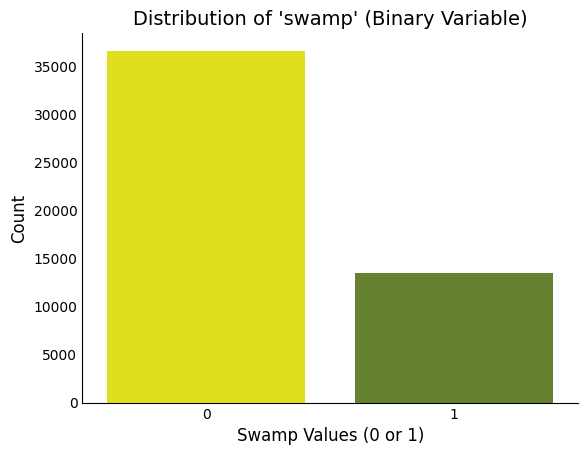

In [ ]:
value_counts = baseline_df_clean["swamp"].value_counts()
print("Value Counts for 'swamp':")
print(value_counts)

# Histogram of swamp variable
ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette=['yellow', 'olivedrab'])

# Customize the plot
ax.set_title("Distribution of 'swamp' (Binary Variable)", fontsize=14)
ax.set_xlabel("Swamp Values (0 or 1)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'], fontsize=10)
ax.tick_params(axis='both', which='both', length=0)  # Set length of ticks to 0

# Despine the plot
sns.despine(top=True, right=True)
We w
plt.grid(False)
plt.show()


### Baseline Model

In [ ]:
#defines a ternary column of 0 (desert), 1 (swamp) or 2(healthful area)
#we considered training on this ternary column, however, since our focus is more so on identifying food swamps
#we decided it would be easier to traing a model of the binary colummn swamp
#def ternaryColumn(row):
#    if row.iloc[0] == True:
#        return 0
#
#    if row.iloc[1] == True:
#        return 1
#
#    if row.iloc[2] == True:
#        return 2

# Convert the 'swamp' boolean column to binary (1 for True, 0 for False)
y = baseline_df_clean["swamp"].astype(int)

# Filter features based on column names starting with 'B'
census_columns = [col for col in baseline_df_clean.columns if col.startswith('B')]
X = baseline_df_clean[census_columns].copy()

We began by splitting the data into training and test sets and standardized the features using StandardScaler to normalize the variables.

For feature selection, we used SelectKBest with the f_classif scoring function, which evaluates each feature's correlation with the target variable using an ANOVA F-test. We selected f_classif instead of f_regression because our target variable is binary (indicating whether an area is a food swamp or not). As for setting the value of K, we set an arbitrary limit of 20. That said, Amin et al's approach used the same threshold of 20 variables when they did an approach of using SHAP values to select variables.

In [ ]:
# Split data into training and test sets
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
trainX = scaler.fit_transform(trainX)
testX = scaler.transform(testX)

# Perform feature selection using SelectKBest
featSelection = SelectKBest(f_classif, k=20)  # Use f_classif for classification problems
trainXReduced = featSelection.fit_transform(trainX, trainY)
testXReduced = featSelection.transform(testX)

# Print the shape of the reduced training data
print(f"Shape of reduced training data: {trainXReduced.shape}")


Shape of reduced training data: (35088, 20)


#### SelectKBest Variables

In [ ]:
# Get the feature column names that were selected
feature_names = X.columns  # Get the original feature names
selected_features = list(feature_names[featSelection.get_support()])

# Filter metadata to get details for the selected features
selected_metadata = census_metadata[census_metadata['variable'].isin(selected_features)]

# Display the metadata for interpretation
print("Metadata for 20 SelectKBest Features:")
selected_metadata


Metadata for 20 SelectKBest Features:


,variable,label,concept
5569,B11001_006E,Estimate!!Total!!Family households!!Other fami...,HOUSEHOLD TYPE (INCLUDING LIVING ALONE)
5577,B11001_004E,Estimate!!Total!!Family households!!Other family,HOUSEHOLD TYPE (INCLUDING LIVING ALONE)
9821,B25014_002E,Estimate!!Total!!Owner occupied,TENURE BY OCCUPANTS PER ROOM
9824,B25014_003E,Estimate!!Total!!Owner occupied!!0.50 or less ...,TENURE BY OCCUPANTS PER ROOM
9941,B25014_010E,Estimate!!Total!!Renter occupied!!0.51 to 1.00...,TENURE BY OCCUPANTS PER ROOM
10029,B25014_009E,Estimate!!Total!!Renter occupied!!0.50 or less...,TENURE BY OCCUPANTS PER ROOM
10042,B25014_008E,Estimate!!Total!!Renter occupied,TENURE BY OCCUPANTS PER ROOM
10307,B03002_003E,Estimate!!Total!!Not Hispanic or Latino!!White...,HISPANIC OR LATINO ORIGIN BY RACE
10498,B03002_014E,Estimate!!Total!!Hispanic or Latino!!Black or ...,HISPANIC OR LATINO ORIGIN BY RACE
10521,B03002_018E,Estimate!!Total!!Hispanic or Latino!!Some othe...,HISPANIC OR LATINO ORIGIN BY RACE


<ipython-input-27-fdd288314788>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-27-fdd288314788>:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


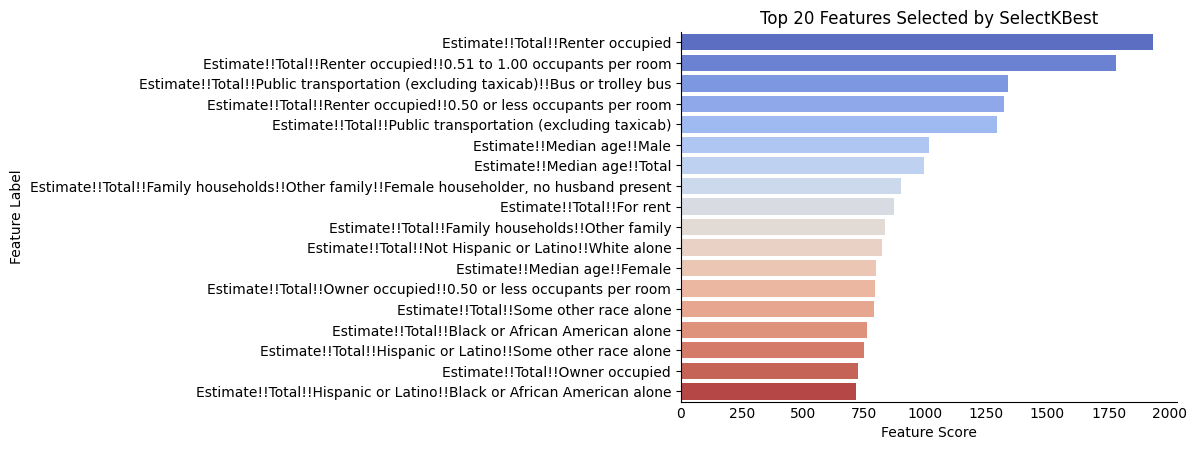

In [ ]:
# get the scores from the selectkbest
selected_scores = featSelection.scores_[featSelection.get_support()]
selected_features = X.columns[featSelection.get_support()]

# Check if 'census_metadata' is defined and contains the required columns
if 'census_metadata' in locals() and 'variable' in census_metadata.columns and 'label' in census_metadata.columns:
    # Map selected features to their labels using the census_metadata
    feature_label_mapping = dict(zip(census_metadata['variable'], census_metadata['label']))
    selected_labels = [feature_label_mapping.get(feature, feature) for feature in selected_features]

    # Update the DataFrame for visualization with labels
    selected_features_df = pd.DataFrame({
        "Feature": selected_labels,
        "Score": selected_scores
    }).sort_values(by="Score", ascending=False)

    #plt.figure(figsize=(10, 6))
    sns.barplot(
    x="Score",
    y="Feature",
    data=selected_features_df,
    palette="coolwarm"
  )

    # Despine top and right spines
    sns.despine(top=True, right=True)

    # Customize ticks
    plt.tick_params(axis='x', length=0)  # Set x-axis tick length to 0
    plt.xlabel("Feature Score")
    plt.ylabel("Feature Label")
    plt.title("Top 20 Features Selected by SelectKBest")

    plt.tight_layout()
    plt.show()
else:
    print("The 'census_metadata' DataFrame or required columns ('variable', 'label') are not available.")


The 20 variables returned are variables relating the housing, Hispanic origin, transportation, race (specifically Black and other), and median ages. Interestingly, the importance of Hispanic, Black, and age are the variables that researchers at Feeding America (the nation-wide foodbank) have identified as being significant with food insecurity. Our model also highlights a few housing variables, which are variables that researchers at Feeding America are planning to bring into their econometric models for future food insecurity estimates.

While this is for food swamps, it is interesting to see that the variables selected through this naive method identifies variables that seem to make some sense, and are not surprising or random.

NOTE: see our Considerations for discussion on potential issues of multicollinearity

In [ ]:
# Initialize Logistic Regression
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Train the model on the training data
logreg.fit(trainXReduced, trainY)

# Predict on the test data
testYPred = logreg.predict(testXReduced)

# Evaluate the model
accuracy = accuracy_score(testY, testYPred)
roc_auc = roc_auc_score(testY, logreg.predict_proba(testXReduced)[:, 1])

print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(testY, testYPred))


Test Accuracy: 0.7383
ROC-AUC Score: 0.7010

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.96      0.84     10967
           1       0.56      0.15      0.24      4071

    accuracy                           0.74     15038
   macro avg       0.66      0.55      0.54     15038
weighted avg       0.70      0.74      0.68     15038



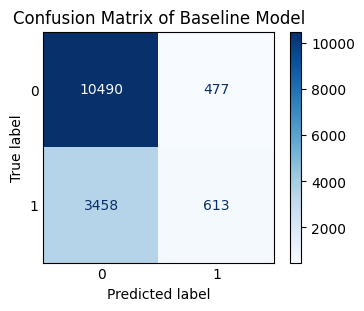

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
conf_matrix = confusion_matrix(testY, testYPred)

# Plot the confusion matrix with custom colors (blues and reds)
fig, ax = plt.subplots(figsize=(4, 3))
ax.tick_params(length = 0)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=logreg.classes_)
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Confusion Matrix of Baseline Model")
plt.show()


The results of our baseline logistic regression model reveal mixed performance, highlighting strengths in identifying non-food swamps but significant challenges in recalling food swamps. The overall test accuracy of 73.8% and a moderate ROC-AUC score of 0.701 indicate that the model performs reasonably well in distinguishing between the two classes. However, accuracy alone is insufficient to gauge the model's effectiveness, particularly given the class imbalance in our dataset.

The classification report provides insights, showing that the model is highly effective at identifying non-food swamps (class 0), with a recall of 96% and an F1-score of 0.84. These metrics reflect the model's ability to minimize false negatives for the majority class, which dominates the dataset. However, for food swamps (class 1), the results are concerning. With a recall of only 15% and an F1-score of 0.24, the model fails to correctly identify most food swamp areas. This poor performance in class 1 significantly undermines the model's utility from a public policy perspective, where identifying food swamps is critical for targeting resources and interventions.

As such, we try to use class weights to address the class imbalance issue:



In [ ]:
#from the classification report, class 1 is not performing as well as class 0
#we will use class weights to try to deal with any class imbalance issues
logreg_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logreg_balanced.fit(trainX, trainY)

# Evaluate
test_preds_logreg = logreg_balanced.predict(testX)
print("Classification Report with Balanced Logistic Regression:")
print(classification_report(testY, test_preds_logreg))


Classification Report with Balanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.66      0.74     10967
           1       0.41      0.64      0.50      4071

    accuracy                           0.66     15038
   macro avg       0.62      0.65      0.62     15038
weighted avg       0.72      0.66      0.67     15038



 Adding class weights improved recall for food swamps (class 1) to 64%, a substantial increase compared to the unbalanced model, though at the expense of reduced precision (41%) and overall accuracy (66%). While the balanced model demonstrates the potential of class weighting to improve recall for the minority class, its limitations in achieving strong precision and F1-scores suggest the need for alternative approaches. These results inform our decision to explore other models like Random Forest and XGBoost.

# Approach and Methodology


As noted in our baseline model, the issue of class imbalance and recall inform our modeling decisions and metrics that we optimize on.

## Models

Given the large number of features available from the ACS, the goal of our project is to take a machine learning approach for feature selection through Random Forest, XGBoost, LASSO Regression, and ensemble methods.

The core goal is to optimize our models not merely for accuracy but for recall for the "swamp" classification because our primary objective is to capture as many actual food swamp areas as possible. From a public policy perspective, misclassifying food swamps can lead to overlooked policy interventions at the locations where it matters most.

Given the large number of features, we considered models that could help with reducing the feature dimensions such as Priciple Componenent Analysis (PCA). However, because it is important for us to understand the specific features that are important in modeling food swamps, we will want to use models that allow us to keep interpretation of individual features. Again, from a policy perspective, understanding the specific demographic, economic or housing characteristics would be important.


### Random Forest

Random Forest (RF) models are ensemble models made up of multiple decision trees, allowing for improved accuracy, and limiting overfitting. We trained a Random Forest classifier and performed feature selection by choosing the 20 features (like in our baseline) with the highest feature importance. We then trained a new RF classifier on just these 20 features to make predictions.

In [ ]:
# Train a RandomForestClassifier on the training data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(trainX, trainY)

# Get feature importances from the trained model
feature_importances = rf.feature_importances_

# Select the top 20 features using SelectFromModel with mean threshold
selector = SelectFromModel(rf, threshold="mean", prefit=True)
trainX_selected = selector.transform(trainX)
testX_selected = selector.transform(testX)

# Get feature names if trainX is a DataFrame
if isinstance(trainX, pd.DataFrame):
    selected_features = trainX.columns[selector.get_support(indices=True)]
    print(f"Selected Features: {selected_features}")

# Train a new RandomForestClassifier on the selected features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(trainX_selected, trainY)

# Evaluate the model
accuracy = rf_selected.score(testX_selected, testY)
print(f"Validation Accuracy: {accuracy:.4f}")


Validation Accuracy: 0.7506


We summarize the performance of our model on the test set, by reporting the accuracy, classification report (precision, recall, f1, and support), and a confusion matrix. Our RF has the highest overall accuracy compared to the LASSO and XGBoost, however, the issue of class imbalance is evident in the recall and f1-score for class 1.

In [ ]:
# Evaluate the model on the test set
y_pred = rf_selected.predict(testX_selected)

# Calculate performance metrics
accuracy = accuracy_score(testY, y_pred)
conf_matrix = confusion_matrix(testY, y_pred)
report = classification_report(testY, y_pred)

# Print the selected feature indices and their names
print("Selected feature indices based on RandomForest:")
#print(selected_feature_indices)
print("\nSelected feature names:")
#print(selected_feature_names)

# Print model performance
print("\nModel Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)


Selected feature indices based on RandomForest:

Selected feature names:

Model Performance on Test Set:
Accuracy: 0.7506

Confusion Matrix:
[[10469   498]
 [ 3252   819]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.85     10967
           1       0.62      0.20      0.30      4071

    accuracy                           0.75     15038
   macro avg       0.69      0.58      0.58     15038
weighted avg       0.72      0.75      0.70     15038



To account for the class imbalance, and to test hyperparameter tuning (optimizing on recall score), we include class weights in our parameter grid and run a randomized search (as to lower compute time) to find an optimal RF model.

In [ ]:
# hyperparameter tuning  on rf
from sklearn.model_selection import GridSearchCV # we tested grid search but runs take up to hours
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score, confusion_matrix


# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Use recall for scoring
recall_scorer = make_scorer(recall_score, average='binary')

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,  # Number of random samples to evaluate
    cv=5,  # 5-fold cross-validation
    scoring=recall_scorer,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit the model
random_search.fit(trainX_selected, trainY)
best_rf = random_search.best_estimator_
print(f"Best RF Parameters: {random_search.best_params_}")

# Evaluate optimized model
optimized_preds = best_rf.predict(testX_selected)
optimized_recall = recall_score(testY, optimized_preds, average='binary')  # Adjust 'average' if needed
print(f"\nOptimized Random Forest Recall: {optimized_recall:.4f}")
print("\nOptimized Random Forest Confusion Matrix:")
print(confusion_matrix(testY, optimized_preds))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


### LASSO Regression

Our third model uses a LASSO logistic regression with cross validation. It  uses the l1 regularization term as a penalty that shrinks coefficients towards zero if the variable is not contributing to the model. We wanted to test this model as it is a common technique for feature selection, and a good fit for our problem of having a large number of features.

To "tune" our LASSO, we implement cross validation which selects the optimal alpha which is the term that is controling the L1 regularization strength, i.e., the penalty term that is used to shrink non-contributing features.


In [ ]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# selected_features = selector_xgb.transform(trainX)  # Uncomment if selector_xgb is used
selected_features = trainX
testX_selected = testX

# Scale the data
scaler = StandardScaler()
selected_features = scaler.fit_transform(selected_features)
testX_selected = scaler.transform(testX_selected)

# Define the range of alphas
alphas = np.logspace(0, 1, 10)

# Logistic Regression with Cross-Validation
logreg_cv = LogisticRegressionCV(
    Cs=alphas,
    penalty='l1',
    solver='saga',
    max_iter=2000, # our solver struggles to converge at 1000 iterations printing warnings
    class_weight='balanced',
    cv=5,
    n_jobs=-1,
    random_state=42
)
logreg_cv.fit(selected_features, trainY)

# Get the best C (regularization strength)
best_c = logreg_cv.C_[0]
print(f"Best C (Regularization Strength): {best_c:.4f}")

# Train the best Logistic Regression model
logreg_best = LogisticRegression(
    C=best_c,
    penalty='l1',
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
logreg_best.fit(selected_features, trainY)

# Predict on the test set
predictions = logreg_best.predict(testX_selected)

# Evaluate the model
accuracy = accuracy_score(testY, predictions)
print(f"Test Accuracy: {accuracy:.4f}")

#recall
recall = recall_score(testY, predictions, pos_label=1)
print(f"Test Recall: {recall:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(testY, predictions))


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best C (Regularization Strength): 1.6681
Test Accuracy: 0.6554
Test Recall: 0.6441

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.66      0.74     10967
           1       0.41      0.64      0.50      4071

    accuracy                           0.66     15038
   macro avg       0.62      0.65      0.62     15038
weighted avg       0.72      0.66      0.67     15038



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


We find that with the LASSO regression optimized, we get the highest recall out of any model. However, the accuracy of this model suffers.

### XGBoost
XGBoost models are a way of implementing gradient boosting. They consist of multiple decision trees, similar to RF models, but the decision trees are used sequentially, unlike in RF models.

As we found across models, the XGBoost performed in a balanced manner between its overall accuracy, and the recall. We decided to continue focusing on XGBoosting as its overall accuracy is better than the LASSO, and its recall is better than RF. We attempt various techniques to deal with the class imbalance issues, and to try to improve the recall and accuracy.


In [ ]:
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

# Save the original feature names before any transformations
feature_names = trainX.columns if isinstance(trainX, pd.DataFrame) else None

# Calculate class weights based on training data
class_counts = pd.Series(trainY).value_counts().sort_index()
total_samples = len(trainY)
class_weights = total_samples / (len(class_counts) * class_counts)

# Map the weights to each sample in the training set
sample_weights = pd.Series(trainY).map(class_weights).values

# Train XGBoostClassifier on the training data
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    #use_label_encoder=False,
    n_estimators=100,
    random_state=42
)

xgb_clf.fit(trainX, trainY, sample_weight=sample_weights)


# Evaluate the model on the original test set
test_predictions = xgb_clf.predict(testX)
test_proba = xgb_clf.predict_proba(testX)[:, 1]


print("Classification Report (XGBoost):")
print(classification_report(testY, test_predictions))

print(f"Test ROC-AUC Score: {roc_auc_score(testY, test_proba):.4f}")
print(f"Test Accuracy: {accuracy_score(testY, test_predictions):.4f}")

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.81      0.74      0.78     10967
           1       0.43      0.53      0.48      4071

    accuracy                           0.69     15038
   macro avg       0.62      0.64      0.63     15038
weighted avg       0.71      0.69      0.69     15038

Test ROC-AUC Score: 0.7118
Test Accuracy: 0.6859


Instead of using the mean importance score that XGBoost generates for features, we cap the number of max features in the following XBG model just to compare what the results would look like at 20 features (similiar to other other models). When we train a XGB on the reduced 20 features, we find that recall increases at the cost of accuracy.

In [ ]:
# Retrain the XGBoostClassifier on the reduced training data
xgb_clf_reduced = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    random_state=42
)

xgb_clf_reduced.fit(trainXReduced, trainY, sample_weight=sample_weights)

#  Use SelectFromModel to perform feature selection
selector_xgb = SelectFromModel(xgb_clf, threshold='mean', prefit=True, max_features=20)
trainXReduced = selector_xgb.transform(trainX)

# Ensure consistent transformation of the test data
testXReduced = selector_xgb.transform(testX)
# Evaluate the retrained model on the reduced test set
test_predictions = xgb_clf_reduced.predict(testXReduced)
test_proba = xgb_clf_reduced.predict_proba(testXReduced)[:, 1]

# Print evaluation metrics
print("Classification Report (XGBoost with Reduced Features):")
print(classification_report(testY, test_predictions))

print(f"Test ROC-AUC Score: {roc_auc_score(testY, test_proba):.4f}")
print(f"Test Accuracy: {accuracy_score(testY, test_predictions):.4f}")


Classification Report (XGBoost with Reduced Features):
              precision    recall  f1-score   support

           0       0.82      0.69      0.75     10967
           1       0.41      0.58      0.48      4071

    accuracy                           0.66     15038
   macro avg       0.62      0.64      0.62     15038
weighted avg       0.71      0.66      0.68     15038

Test ROC-AUC Score: 0.7115
Test Accuracy: 0.6645


#### SMOTE

As we have seen in the previous XGB iterations, we noticed that precision and recall was significantly better for class 0 than for class 1, indicating a class imbalance issue. We try addressing this class imbalance issue by applying SMOTE (Synthetic Minority Over-sampling Technique), which focuses on samples in the minority class and generates synthetic samples to balance the class distribution. By implementing SMOTE, we aim to minimize bias towards the majority class. To implement both SMOTE and and hyperparameter tuning, we will use regular trainX because our results showed training a new XGBoost on a reduced feature set produced worst results.

In [ ]:

# Apply SMOTE to trainXreduced and trainY
smote = SMOTE(random_state = 42)
trainX_smote, trainY_smote = smote.fit_resample(trainXReduced, trainY)

#train new model with smote data
xgb_clf_smote = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    random_state=42
)

# Train the XGBoost model on the SMOTE-balanced data
xgb_clf_smote.fit(trainX_smote, trainY_smote)

# Evaluate the SMOTE model on the original test set
smote_test_predictions = xgb_clf_smote.predict(testXReduced)
smote_test_proba = xgb_clf_smote.predict_proba(testXReduced)[:, 1]

# Print evaluation metrics for the SMOTE model
print("Classification Report (XGBoost with SMOTE):")
print(classification_report(testY, smote_test_predictions))

print(f"Test ROC-AUC Score (SMOTE): {roc_auc_score(testY, smote_test_proba):.4f}")
print(f"Test Accuracy (SMOTE): {accuracy_score(testY, smote_test_predictions):.4f}")


Classification Report (XGBoost with SMOTE):
              precision    recall  f1-score   support

           0       0.80      0.76      0.78     10967
           1       0.44      0.49      0.46      4071

    accuracy                           0.69     15038
   macro avg       0.62      0.63      0.62     15038
weighted avg       0.70      0.69      0.70     15038

Test ROC-AUC Score (SMOTE): 0.6999
Test Accuracy (SMOTE): 0.6897


We rerun the XGBoosting after training the XGB classifier on the selected features after applying SMOTE. We obtain a small increase in some metrics such as the recall for swamps, but at a trade off of recall for non swamps. Additionally, the ROC-AUC suffers very slightly, and test accuracy falls.

#### XGB Hyperparameter Tuning
Below, we will do hyperparameter tuning and instead of scoring based off of accuracy, we will use the recall score by defining the recall_scorer and using that as the scoring metric for our search. We use RandomizedSearch instead of grid to cut down on the compute time as GridSearch was computationally heavy and leading to lengthy run times.

In [ ]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the parameter grid
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

# Define the XGBoost classifier
xgb_clf = XGBClassifier(random_state=42)

# Use recall as the scoring metric
recall_scorer = make_scorer(recall_score, pos_label=1) # we want to recall swamps so set to 1

# Perform Randomized Search with Recall Optimization
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    scoring=recall_scorer,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit the randomized search to the training data
random_search.fit(trainX, trainY, sample_weight=sample_weights)

# Best parameters and model
best_xgb = random_search.best_estimator_
print(f"\nBest Parameters: {random_search.best_params_}")

# Train the best model on the training set
best_xgb.fit(trainX, trainY, sample_weight=sample_weights)

# Predictions and evaluation
test_preds = best_xgb.predict(testX)

# Evaluate model
accuracy = accuracy_score(testY, test_preds)
print(f"Accuracy of Optimized XGBoost: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(testY, test_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(testY, test_preds))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}
Accuracy of Optimized XGBoost: 0.7309

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83     10967
           1       0.51      0.28      0.36      4071

    accuracy                           0.73     15038
   macro avg       0.64      0.59      0.60     15038
weighted avg       0.70      0.73      0.70     15038


Confusion Matrix:
[[9851 1116]
 [2930 1141]]


Interestingly, despite setting the recall score to be the metric that is optimized in our tuning, the recall for the larger class seemed to have dominated the tuning and led to higher recall for non-swamps, but less recall for swamps.

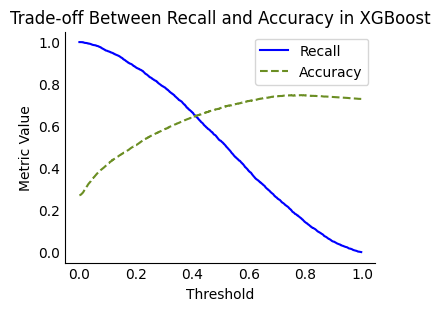

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, accuracy_score

# Get probabilities and thresholds
y_proba = xgb_clf.predict_proba(testX)[:, 1]
precision, recall, thresholds = precision_recall_curve(testY, y_proba)

# Compute accuracy at each threshold
accuracy = [accuracy_score(testY, y_proba >= t) for t in thresholds]

# Compute ROC curve and AUC
fpr, tpr, roc_thresholds = roc_curve(testY, y_proba)
roc_auc = roc_auc_score(testY, y_proba)
# Plot recall vs. accuracy
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(thresholds, recall[:-1], label="Recall", color="blue")
ax.plot(thresholds, accuracy, label="Accuracy", linestyle='--', color='olivedrab')
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Trade-off Between Recall and Accuracy in XGBoost")
ax.legend()
ax.grid(False)

#remove axes ticks
ax.tick_params(length = 0)

# Despine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


####Ensemble Model

Lastly, one potential avenue for improving model performance is leveraging model stacking. Stacking involves training multiple base models and then combining their predictions through a "meta-learner" to optimize overall performance. In our case, we experimented with stacking Random Forest (RF) and XGBoost models, using logistic regression as the meta-learner to integrate their outputs. The stacked model achieved comparable accuracy to the Random Forest model while slightly improving recall. However, the recall of the base XGBoost model remained higher, suggesting that for our specific task of food swamp classification, the standalone XGBoost model remains the most effective choice for maximizing recall.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(trainX, trainY)

# Train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(trainX, trainY)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [21:09:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
rf_preds_train = rf_model.predict_proba(trainX)  # Probabilities from RF
xgb_preds_train = xgb_model.predict_proba(trainX)  # Probabilities from XGBoost

rf_preds_test = rf_model.predict_proba(testX)  # Probabilities from RF (test set)
xgb_preds_test = xgb_model.predict_proba(testX)  # Probabilities from XGBoost (test set)


In [ ]:
import numpy as np

# Stack the predictions
train_meta = np.hstack((rf_preds_train, xgb_preds_train))
test_meta = np.hstack((rf_preds_test, xgb_preds_test))


In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(train_meta, trainY)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
meta_preds_test = meta_model.predict(test_meta)

from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
ensemble_accuracy = accuracy_score(testY, meta_preds_test)
print(f'Ensemble Test Accuracy: {ensemble_accuracy:.4f}')

#recall
ensemble_recall = recall_score(testY, meta_preds_test, pos_label=1)
print(f'Ensemble Test Recall: {ensemble_recall:.4f}')

# Classification report
print(classification_report(testY, meta_preds_test))


Ensemble Test Accuracy: 0.7451
Ensemble Test Recall: 0.3090
              precision    recall  f1-score   support

           0       0.78      0.91      0.84     10967
           1       0.55      0.31      0.40      4071

    accuracy                           0.75     15038
   macro avg       0.67      0.61      0.62     15038
weighted avg       0.72      0.75      0.72     15038



#Results and Discussion


## Model Validation
After testing these models, we are selecting XGBoost as our final model because it demonstrated the highest recall for identifying food swamps. Recall is our priority metric because we aim to ensure that as many actual food swamp areas as possible are flagged by the model, even if that comes at a slight cost to overall accuracy.


In this part, we will conduct a hypothesis test to determine if our trained XGBoost model's performance (in terms of ROC-AUC score) is better than random.

To determine whether we can reject or fail to reject the null hypothesis, we will take the reported ROC-AUC accuracy of our XGBoost model and follow the steps below:

1.   Set up the hypotheses:
  * $H_0$: The XGBoost model's performance is no better than what would be expected by chance if the relationship between features and labels were random.
  * $H_a$ (alternative hypothesis): The XGBoosting model's performance is better than random.

2. Simulate random outcomes: We shuffle the test outcomes (testY) to simulate random predictions, which simulates the condition where there is no relationship between the features and outcome ("guessing randomly").

3. Compare observed results to simulations: We will determine how often the simulated results produce ROC-AUC scores as extreme or more extreme than the observed data. This will give us a **p-value**, which tells us the likelihood of observing the current data under the null hypothesis.

5. Make a decision: Based on the p-value, we will decide whether to reject or fail to reject the null hypothesis:
  * If the p-value is below a threshold (in this case we'll use 0.05), we will reject the null hypothesis and conclude that the XGBoost model performs significantly better than random guessing.
  * If the p-value is higher, we will fail to reject the null hypothesis, suggesting the model's performance is no better than random.

In [ ]:
from sklearn.metrics import roc_auc_score

# Simulate random predictions for a baseline comparison
num_simulations = 10_000
random_roc_auc_scores = []

for _ in range(num_simulations):
    # Randomize the predictions across testY randomly
    random_predictions = np.random.permutation(testY)
    # Calculate the ROC-AUC for random predictions
    random_roc_auc = roc_auc_score(testY, random_predictions)
    random_roc_auc_scores.append(random_roc_auc)

# Observed ROC-AUC from the trained model
observed_roc_auc = 0.70115

# Calculate p-value: proportion of random scores >= observed score
p_value = np.sum(np.array(random_roc_auc_scores) >= observed_roc_auc) / num_simulations

print(f"Observed ROC-AUC: {observed_roc_auc}")
print(f"P-value: {p_value}")

# Decision rule
if p_value < 0.05:
    print("Reject the null hypothesis: The model performs better than random.")
else:
    print("Fail to reject the null hypothesis: The model does not show evidence of better-than-random performance.")


Observed ROC-AUC: 0.70115
P-value: 0.0
Reject the null hypothesis: The model performs better than random.


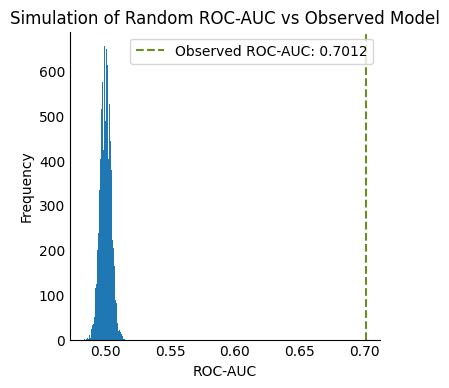

In [ ]:
# Plot the distribution of simulated ROC-AUC scores
# In addition: plot our observed AUC-AUC
fig, ax = plt.subplots(figsize=(4, 4))

plt.axvline(x=observed_roc_auc, color='olivedrab', linestyle='dashed',
            label=f'Observed ROC-AUC: {observed_roc_auc:.4f}')
plt.hist(random_roc_auc_scores, bins=50)
# Set labels and title
ax.set_xlabel('ROC-AUC')
ax.set_ylabel('Frequency')
ax.set_title('Simulation of Random ROC-AUC vs Observed Model')

# Remove spines on top and right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend()
plt.grid(False)
ax.tick_params(length = 0)
plt.show()

##Interpreting Features from XGB

It's important to note that since we decided to use a XGBoost model, while we still preserve individual features and can interpret them, they will not have the same interpretability as a general Linear Model such as OLS where we can interpret their coefficients. That said, we can interpret these variables selected by our best XGBoost model as the variables that recall whether a census tract is a food swamp.

In [ ]:
# Perform feature selection
selected_feature_indices_xgb = selector_xgb.get_support(indices=True)

# Map indices to feature names
selected_feature_names_xgb = [feature_names[i] for i in selected_feature_indices_xgb]

selected_metadata_xgb = census_metadata[census_metadata['variable'].isin(selected_feature_names_xgb)]

# Print the selected feature names
print("Selected Features Based on XGBoost:")
selected_metadata_xgb

Selected Features Based on XGBoost:


,variable,label,concept
5569,B11001_006E,Estimate!!Total!!Family households!!Other fami...,HOUSEHOLD TYPE (INCLUDING LIVING ALONE)
6088,B25034_010E,Estimate!!Total!!Built 1939 or earlier,YEAR STRUCTURE BUILT
6338,B25034_008E,Estimate!!Total!!Built 1950 to 1959,YEAR STRUCTURE BUILT
6359,B25034_004E,Estimate!!Total!!Built 1990 to 1999,YEAR STRUCTURE BUILT
9824,B25014_003E,Estimate!!Total!!Owner occupied!!0.50 or less ...,TENURE BY OCCUPANTS PER ROOM
9941,B25014_010E,Estimate!!Total!!Renter occupied!!0.51 to 1.00...,TENURE BY OCCUPANTS PER ROOM
10302,B03002_004E,Estimate!!Total!!Not Hispanic or Latino!!Black...,HISPANIC OR LATINO ORIGIN BY RACE
10307,B03002_003E,Estimate!!Total!!Not Hispanic or Latino!!White...,HISPANIC OR LATINO ORIGIN BY RACE
10329,B03002_007E,Estimate!!Total!!Not Hispanic or Latino!!Nativ...,HISPANIC OR LATINO ORIGIN BY RACE
10336,B03002_006E,Estimate!!Total!!Not Hispanic or Latino!!Asian...,HISPANIC OR LATINO ORIGIN BY RACE


Interestingly, the most important feature was the number of renters in a census tract. (There are other features on housing too such as the year the building in a census tract were built, with other features mostly on race.) This is interesting as it tracks with what research shows in a related area of food insecurity. In fact, Feeding America's research team is considering including housing terms in their econometric models for estimating food insecurity rates.

One other observation is the inclusion of transportation variables in our XGBoost model (second most important) which suggests that public transportation plays a role in an area's access to healthy foods.

While our report is on a related issue of food access: food swamps, it is nonetheless interesting to see these similar features in our model.



<ipython-input-118-3b0f3d0aebd7>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


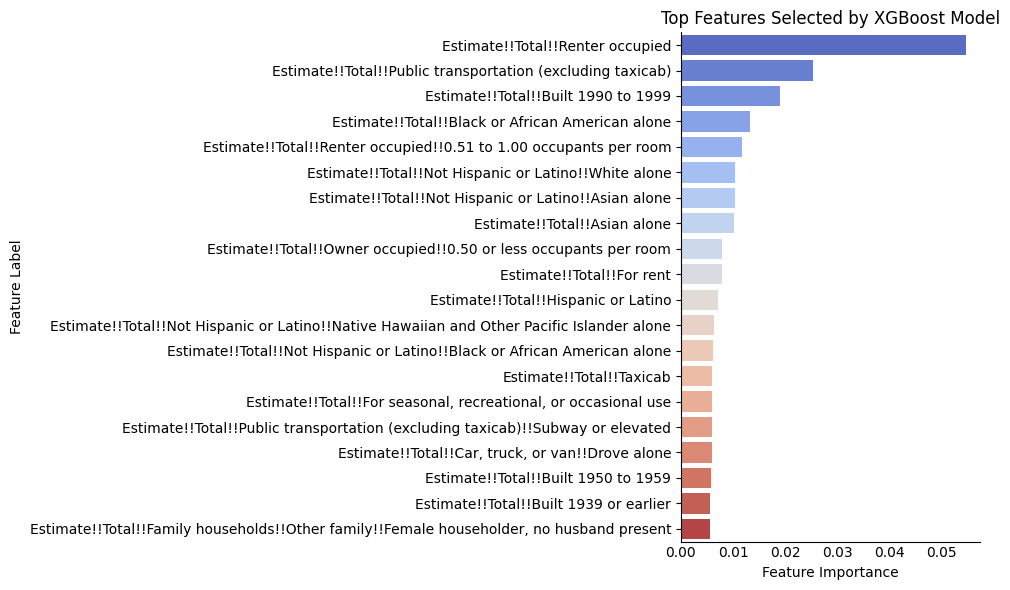

In [ ]:
# Assuming `selector_xgb` is a SelectFromModel instance using an XGBoost model
# and `census_metadata` is defined with 'variable' and 'label' columns.

if 'selector_xgb' in locals() and 'census_metadata' in locals() and 'variable' in census_metadata.columns and 'label' in census_metadata.columns:
    # Get the model used in SelectFromModel
    xgb_model = selector_xgb.estimator  # Access the model
    feature_importances_xgb = xgb_model.feature_importances_

    # Get indices of selected features
    selected_feature_indices_xgb = selector_xgb.get_support(indices=True)
    selected_importances_xgb = feature_importances_xgb[selected_feature_indices_xgb]

    # Map indices to feature names and labels
    selected_feature_names_xgb = [feature_names[i] for i in selected_feature_indices_xgb]
    feature_label_mapping_xgb = dict(zip(census_metadata['variable'], census_metadata['label']))
    selected_labels_xgb = [feature_label_mapping_xgb.get(feature, feature) for feature in selected_feature_names_xgb]

    # Create a DataFrame for visualization
    selected_features_xgb_df = pd.DataFrame({
        "Feature": selected_labels_xgb,
        "Importance": selected_importances_xgb
    }).sort_values(by="Importance", ascending=False)

    # Plot the feature importances with labels
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=selected_features_xgb_df,
        palette="coolwarm"
    )

    # Despine top and right spines
    sns.despine(top=True, right=True)

    # Customize ticks
    plt.tick_params(axis='x', length=0)  # Set x-axis tick length to 0
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Label")
    plt.title("Top Features Selected by XGBoost Model")

    plt.tight_layout()
    plt.show()
else:
    print("Ensure `selector_xgb` is fitted and `census_metadata` with the required columns is available.")


## Considerations


### Feature Engineering

Potential improvements to our model could involve feature engineering to better capture the nuances of variables influencing food swamps. While our project aimed to retain as many Census variables as possible in their original form, focusing solely on feature selection allowed us to identify predictors without altering the data. This approach aligns with our goal of understanding how existing Census variables contribute to the phenomenon. However, incorporating feature engineering—such as transforming variables (count to percents), creating interaction terms, or aggregating features—could reveal deeper relationships and improve model performance, though at the cost of departing from the original variables' unaltered state.

###Spatial Autocorrelation
 When we merged in our geometry data based on the FIPs, there were missing data for some census tracts and we were  left with a dataset that was less than 50K rows. For the purposes of this report, we did not use the spatial component for our analysis.

That said, a future consideration would be to include the spatial terms in our modeling as the presence of spatial autocorrelation can violate the independence assumption for models like OLS and lead to bias in the results. While our report used machine learning techniques like Random Forest, and XGBoosting that don't necessarily have the assumptions of OLS, the presence of spatial autocorrelation could still have been accounted for by creating a spatially lagged variable of the dependent variable to include in the features and seeing if the models select the spatially lagged variable.

 We did use the standard test for spatial autocorrelation, the Moran's I, on the geodataframe that had less than 50K rows. Moran's I values range from -1 to 1, with values close to 0 indicating no spatial clustering. Significance of the Moran's I statistic is tested through 999 permutation tests to estimate an empirical p-value. Low p-values can suggest a significant Moran's I statistic.

The results from our Moran's I test suggest that there is a moderate positive presence of geospatial autocorrelation:
*   Moran's I: 0.31117566585242484
*   p-value: 0.001
*   z-score: 62.89134694273729

However, we reiterate that since this required a dataframe with less than 50K observations, we did not use this geospatial data our modeling.

#Conclusion

In this project, we sought to predict the presence of food swamps across U.S. census tracts by leveraging demographic and socio-economic variables from Census data, combined with the CDC's modified Retail Food Environment Index (mRFEI). Our data-driven approach allowed us to explore the relationships between community characteristics and food access.

Our modeling approach began with feature selection to identify the most relevant predictors while leaving variables unchanged to preserve the original data's integrity. This approach was aligned with our goal of understanding how unaltered Census characteristics relate to food swamp classification. Throughout the modeling process, we prioritized recall, ensuring that areas identified as food swamps were accurately captured, even if it meant tolerating a higher false-positive rate. To address class imbalance in the data, we explored several strategies, including hyperparameter tuning, applying class weights, and oversampling the minority class using SMOTE. After evaluating multiple configurations, we selected an XGBoost model with class weights, which demonstrated the best balance of recall and accuracy.

This model not only performed well but also allowed us to identify the most influential Census variables for food swamp classification. The results were interesting as they overlap with research in food insecurity, highlighting housing and race (specifically Black and Hispanic) as variables that are important. To validate our results, we implemented simulation-based hypothesis testing to assess the statistical significance of the ROC-AUC score achieved by the XGBoost model. This robust validation process reinforced our confidence in the model’s ability to distinguish food swamps effectively and provided a solid foundation for interpreting the variable importance rankings derived from it.

While feature engineering could improve predictive performance, our decision to minimize variable manipulation stemmed from a commitment to understanding existing relationships rather than creating new ones. Future considerations should also be paid to accounting for geospatial autocorrelation.


